<a href="https://colab.research.google.com/github/SiracencoSerghei/Bootcamp_Python/blob/master/day_73/Programming_Languages.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **Goal:** Analyze the popularity of different programming languages ​​over time
---

StackOverflow will help us answer this burning question. Every post on Stack OverFlow has a tag. And that tag can be the name of a programming language.

To determine which language is the most popular, all we need to do is count the number of posts on Stack Overflow that are tagged with each language. The language with the most posts wins!

Today you will learn:

How to visualize data and create charts with Matplotlib

How to summarize, group, and manipulate your data with Pandas to get it in the format you want

How to work with timestamps and time series data

How to create and customize a line chart to your liking

## Get the Data

Either use the provided .csv file or (optionally) get fresh (the freshest?) data from running an SQL query on StackExchange:

Follow this link to run the query from [StackExchange](https://data.stackexchange.com/stackoverflow/query/675441/popular-programming-languages-per-over-time-eversql-com) to get your own .csv file

<code>
select dateadd(month, datediff(month, 0, q.CreationDate), 0) m, TagName, count(*)
from PostTags pt
join Posts q on q.Id=pt.PostId
join Tags t on t.Id=pt.TagId
where TagName in ('java','c','c++','python','c#','javascript','assembly','php','perl','ruby','visual basic','swift','r','object-c','scratch','go','swift','delphi')
and q.CreationDate < dateadd(month, datediff(month, 0, getdate()), 0)
group by dateadd(month, datediff(month, 0, q.CreationDate), 0), TagName
order by dateadd(month, datediff(month, 0, q.CreationDate), 0)
</code>

---
# **Import Statements**
---

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

In [37]:
from google.colab import files
uploaded = files.upload()

Saving QueryResults.csv to QueryResults (1).csv


---
# Data Exploration
---

**Challenge**: Read the .csv file and store it in a Pandas dataframe

In [38]:
df = pd.read_csv('QueryResults.csv')

**Challenge**: Examine the first 5 rows and the last 5 rows of the of the dataframe

In [39]:
df.head()

,m,TagName,Unnamed: 2
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,7
2,2008-08-01 00:00:00,c,78
3,2008-08-01 00:00:00,c#,492
4,2008-08-01 00:00:00,c++,157


In [40]:
df.tail()

,m,TagName,Unnamed: 2
2727,2024-12-01 00:00:00,php,498
2728,2024-12-01 00:00:00,python,2984
2729,2024-12-01 00:00:00,r,575
2730,2024-12-01 00:00:00,ruby,54
2731,2024-12-01 00:00:00,swift,357


**Challenge:** try to provide these column names: ['DATE', 'TAG', 'POSTS']

In [41]:
# df.rename(columns={'m': 'DATE', 'TagName': 'TAG', 'Unnamed: 2': 'POSTS'}, inplace=True)
# df = df.rename(columns={'m': 'DATE', 'TagName': 'TAG', 'Unnamed: 2': 'POSTS'})
df.columns = ['DATE', 'TAG', 'POSTS']
df.head()

,DATE,TAG,POSTS
0,2008-07-01 00:00:00,c#,3
1,2008-08-01 00:00:00,assembly,7
2,2008-08-01 00:00:00,c,78
3,2008-08-01 00:00:00,c#,492
4,2008-08-01 00:00:00,c++,157


**Challenge:** Check how many rows and how many columns there are.
What are the dimensions of the dataframe?

In [42]:
print( f'The dimensions of the dataframe is {df.shape[0]} rows and {df.shape[1]} columns')

The dimensions of the dataframe is 2732 rows and 3 columns


**Challenge**: Count the number of entries in each column of the dataframe

To count the number of entries in each column we can use .count().

Note that .count() will actually tell us the number of non-NaN values in each column.

In [43]:
column_counts = df.count()
column_counts

,0
DATE,2732
TAG,2732
POSTS,2732


**Challenge**: Calculate the total number of post per language.
Which Programming language has had the highest total number of posts of all time?

In order to look at the number of entries and the number of posts by programming language, we need to make use of the .groupby() method.

The key is combining .groupby() with the TAG column, which holds as our categories (the names of the programming languages).

If we .sum() the number of posts then we can see how many posts each programming language had since the creation of Stack Overflow.

In [44]:
grouped_df = df.groupby('TAG').sum()
grouped_df = grouped_df.drop(columns='DATE')
grouped_df



,POSTS
TAG,
assembly,43425
c,393714
c#,1584567
c++,790733
delphi,50896
go,72723
java,1873598
javascript,2462326
perl,66983


Some languages are older (e.g., C) and other languages are newer (e.g., Swift). The dataset starts in September 2008.

**Challenge**: How many months of data exist per language? Which language had the fewest months with an entry?


In [45]:
grouped_df = df.groupby('TAG').count()
grouped_df

,DATE,POSTS
TAG,,
assembly,197,197
c,197,197
c#,198,198
c++,197,197
delphi,197,197
go,182,182
java,197,197
javascript,197,197
perl,197,197


---
# Data Cleaning
---

Let's fix the date format to make it more readable. We need to use Pandas to change format from a string of "2008-07-01 00:00:00" to a datetime object with the format of "2008-07-01"

In [46]:
df['DATE'][0]

'2008-07-01 00:00:00'

In [47]:
df.DATE[1]

'2008-08-01 00:00:00'

In [48]:
type(df.DATE[1])

str

In [49]:
df['DATE'] = pd.to_datetime(df['DATE'])
df.head(2)

,DATE,TAG,POSTS
0,2008-07-01,c#,3
1,2008-08-01,assembly,7


---
# Data Manipulation
---

In [50]:
test_df = pd.DataFrame({'Age': ['Young', 'Young', 'Young', 'Young', 'Old', 'Old', 'Old', 'Old'],
                        'Actor': ['Jack', 'Arnold', 'Keanu', 'Sylvester', 'Jack', 'Arnold', 'Keanu', 'Sylvester'],
                        'Power': [100, 80, 25, 50, 99, 75, 5, 30]})
test_df

,Age,Actor,Power
0,Young,Jack,100
1,Young,Arnold,80
2,Young,Keanu,25
3,Young,Sylvester,50
4,Old,Jack,99
5,Old,Arnold,75
6,Old,Keanu,5
7,Old,Sylvester,30


**Challenge**: What are the dimensions of our new dataframe? How many rows and columns does it have? Print out the column names and print out the first 5 rows of the dataframe.

In [51]:
pivoted_df = test_df.pivot(index='Age', columns='Actor', values='Power')
pivoted_df

Actor,Arnold,Jack,Keanu,Sylvester
Age,,,,
Old,75,99,5,30
Young,80,100,25,50


In [52]:
reshaped_df = df.pivot(index='DATE', columns='TAG', values='POSTS')
reshaped_df

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2008-08-01,7.0,78.0,492.0,157.0,11.0,NaN,214.0,158.0,26.0,154.0,116.0,NaN,66.0,NaN
2008-09-01,26.0,292.0,1525.0,699.0,93.0,NaN,1032.0,579.0,120.0,411.0,507.0,3.0,274.0,NaN
2008-10-01,15.0,267.0,1816.0,743.0,101.0,NaN,1053.0,661.0,109.0,513.0,480.0,NaN,234.0,NaN
2008-11-01,13.0,221.0,1510.0,658.0,129.0,NaN,856.0,488.0,79.0,417.0,417.0,1.0,143.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,112.0,479.0,1813.0,1007.0,83.0,208.0,1189.0,2440.0,37.0,784.0,4451.0,875.0,103.0,536.0
2024-09-01,86.0,444.0,1557.0,980.0,67.0,153.0,1266.0,2156.0,26.0,602.0,3678.0,744.0,82.0,504.0
2024-10-01,89.0,464.0,1590.0,918.0,86.0,177.0,1514.0,1876.0,21.0,647.0,3478.0,779.0,63.0,454.0


In [53]:
reshaped_df.shape

(198, 14)

**Challenge**: Count the number of entries per programming language. Why might the number of entries be different?

In [54]:
reshaped_df.notnull().sum()

,0
TAG,
assembly,197
c,197
c#,198
c++,197
delphi,197
go,182
java,197
javascript,197
perl,197


In [60]:
reshaped_df.fillna(0, inplace=True) # ==  reshaped_df = reshaped_df.fillna(0)
reshaped_df.head()

TAG,assembly,c,c#,c++,delphi,go,java,javascript,perl,php,python,r,ruby,swift
DATE,,,,,,,,,,,,,,
2008-07-01,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2008-08-01,7.0,78.0,492.0,157.0,11.0,0.0,214.0,158.0,26.0,154.0,116.0,0.0,66.0,0.0
2008-09-01,26.0,292.0,1525.0,699.0,93.0,0.0,1032.0,579.0,120.0,411.0,507.0,3.0,274.0,0.0
2008-10-01,15.0,267.0,1816.0,743.0,101.0,0.0,1053.0,661.0,109.0,513.0,480.0,0.0,234.0,0.0
2008-11-01,13.0,221.0,1510.0,658.0,129.0,0.0,856.0,488.0,79.0,417.0,417.0,1.0,143.0,0.0


In [61]:

print(len(reshaped_df.columns))
list(reshaped_df.columns)

14


['assembly',
 'c',
 'c#',
 'c++',
 'delphi',
 'go',
 'java',
 'javascript',
 'perl',
 'php',
 'python',
 'r',
 'ruby',
 'swift']

In [62]:
reshaped_df.count()

,0
TAG,
assembly,198
c,198
c#,198
c++,198
delphi,198
go,198
java,198
javascript,198
perl,198


In [63]:
reshaped_df.isna().values.any()

False

---
# Data Visualisaton with with Matplotlib
---

**Challenge**: Use the [matplotlib documentation](https://matplotlib.org/3.2.1/api/_as_gen/matplotlib.pyplot.plot.html#matplotlib.pyplot.plot) to plot a single programming language (e.g., java) on a chart.

**Styling the Chart**

Let's look at a couple of methods that will help us style our chart:

**.figure()** - allows us to resize our chart

**.xticks()** - configures our x-axis

.**yticks()** - configures our y-axis

**.xlabel()** - add text to the x-axis

**.ylabel()** - add text to the y-axis

**.ylim()**- allows us to set a lower and upper bound

In [79]:
java_data = df[df['TAG'] == 'java']
java_data.head()

,DATE,TAG,POSTS
6,2008-08-01,java,214
17,2008-09-01,java,1032
29,2008-10-01,java,1053
40,2008-11-01,java,856
52,2008-12-01,java,707


**Challenge**: Show two line (e.g. for Java and Python) on the same chart.

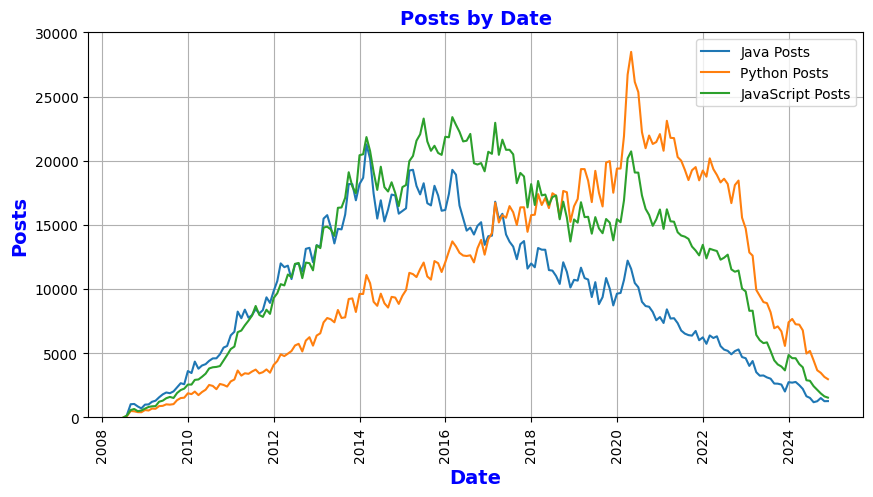

In [112]:
# Define the figure size
plt.figure(figsize=(10, 5))

# Rotate x-ticks for better readability
plt.xticks(rotation=90)

# Add labels for the axes
plt.xlabel('Date', fontsize=14, fontweight='bold', color='blue')
plt.ylabel('Posts', fontsize=14, fontweight='bold', color='blue')

# Set y-axis limits
plt.ylim(0, 30000)

# Plot the data with labels for the legend
line1, = plt.plot(java_data.DATE, java_data.POSTS, label='Java Posts')
line2, = plt.plot(reshaped_df.index, reshaped_df['python'], label='Python Posts')
line3, = plt.plot(reshaped_df.index, reshaped_df['javascript'], label='JavaScript Posts')

# Set the title of the plot
plt.title('Posts by Date', fontsize=14, fontweight='bold', color='blue')

# Show the legend automatically, based on labels provided in plot
plt.legend()

# Enable the grid
plt.grid(True)

# Display the plot
plt.show()


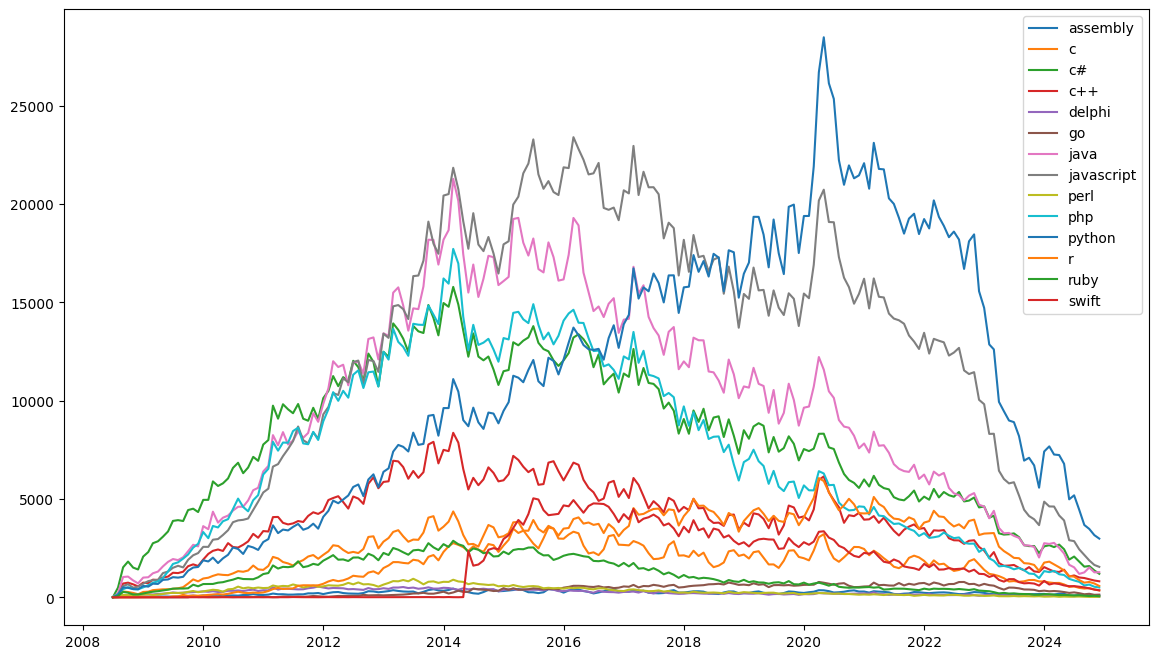

In [116]:
plt.figure(figsize=(14, 8))
for column in reshaped_df.columns:
    plt.plot(reshaped_df.index, reshaped_df[column])
plt.legend(reshaped_df.columns)
plt.show()

---
# Smoothing out Time Series Data
---

Time series data can be quite noisy, with a lot of up and down spikes. To better see a trend we can plot an average of, say 6 or 12 observations. This is called the rolling mean. We calculate the average in a window of time and move it forward by one overservation. Pandas has two handy methods already built in to work this out: [rolling()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.rolling.html) and [mean()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.core.window.rolling.Rolling.mean.html).

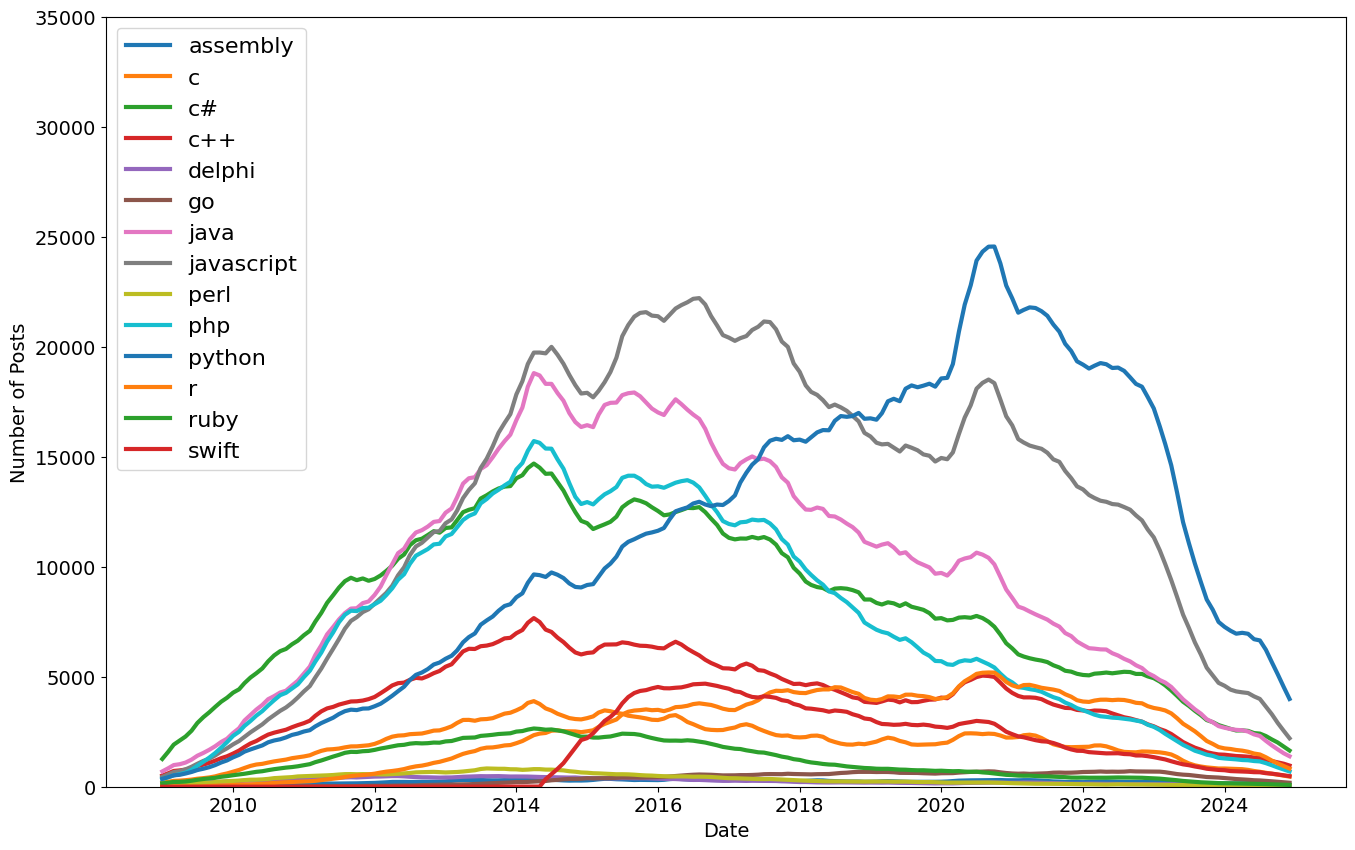

In [120]:
# The window is number of observations that are averaged
roll_df = reshaped_df.rolling(window=7).mean()

plt.figure(figsize=(16,10))
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Number of Posts', fontsize=14)
plt.ylim(0, 35000)

# plot the roll_df instead
for column in roll_df.columns:
    plt.plot(roll_df.index, roll_df[column],
             linewidth=3, label=roll_df[column].name)

plt.legend(fontsize=16)